In [36]:
# Data manipulation
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Load processed dataset
from pandas import set_option


df = pd.read_csv("C:\\Users\\esomw\\OneDrive\\Documents\\DataScience_Workspace\\Fraud_Detection_Project\\data\\nova_pay_eda_ready.csv")
set_option("display.max_columns", None) 
# Preview
df.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,transaction_hour,log_amount_usd,log_fee,log_exchange_rate
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,False,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,18,5.631893,1.658228,0.854990
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,True,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,20,5.045294,1.656321,2.621666
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,False,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,23,5.083452,1.308333,2.097141
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,False,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1,4.101155,1.169381,0.655407
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,False,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,9,5.308070,1.528228,4.434777


# Define Target Variable

In [38]:
# Target variable
target = "is_fraud"

In [39]:
# Preview timestamp and extracted transaction hour

print(
    df[["timestamp", "transaction_hour"]].head(10)
)

                          timestamp  transaction_hour
0  2022-10-03 18:40:59.468549+00:00                18
1  2022-10-03 20:39:38.468549+00:00                20
2  2022-10-03 23:02:43.468549+00:00                23
3  2022-10-04 01:08:53.468549+00:00                 1
4  2022-10-04 09:35:03.468549+00:00                 9
5  2022-10-04 12:09:59.468549+00:00                12
6  2022-10-04 12:37:41.468549+00:00                12
7  2022-10-04 16:27:44.468549+00:00                16
8  2022-10-04 21:00:36.468549+00:00                21
9  2022-10-04 21:20:42.468549+00:00                21


## Drop Non-Predictive Columns (timestamp)

In [40]:
df = df.drop(columns=["timestamp"])

## Separate Features and Target

In [41]:
# Features
X = df.drop("is_fraud", axis=1)

# Target
y = df["is_fraud"]

## Apply One-Hot Encoding on Categorical Variables

In [42]:
# Convert categorical variables into binary dummy variables
X = pd.get_dummies(
    X,
    drop_first=True
)

# Preview encoded dataset
set_option("display.max_columns", None)
print(X.head())

   amount_src  amount_usd   fee  exchange_rate_src_to_dest  new_device  \
0      278.19      278.19  4.25                   1.351351       False   
1      208.51      154.29  4.24                  12.758621        True   
2      160.33      160.33  2.70                   7.142857       False   
3       59.41       59.41  2.22                   0.925926       False   
4      200.96      200.96  3.61                  83.333333       False   

   location_mismatch  ip_risk_score  account_age_days  device_trust_score  \
0              False          0.123               263               0.522   
1              False          0.569               947               0.475   
2              False          0.437               367               0.939   
3              False          0.594               147               0.551   
4              False          0.121               257               0.894   

   chargeback_history_count  risk_score_internal  txn_velocity_1h  \
0                      

In [43]:
# Display first 5 rows of encoded variables

# Get only encoded (transformed) columns

encoded_columns = [
    col for col in X.columns
    if "_" in col
]

X[encoded_columns].head()

,amount_src,amount_usd,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,transaction_hour,log_amount_usd,log_fee,log_exchange_rate,home_country_uk,home_country_unknown,home_country_us,source_currency_gbp,source_currency_usd,dest_currency_cny,dest_currency_eur,dest_currency_gbp,dest_currency_inr,dest_currency_mxn,dest_currency_ngn,dest_currency_php,dest_currency_usd,channel_mobile,channel_unknown,channel_web,ip_country_uk,ip_country_unknown,ip_country_us,kyc_tier_low,kyc_tier_standard,kyc_tier_unknown
0,278.19,278.19,1.351351,False,False,0.123,263,0.522,0,0.223,0,0,0.0,18,5.631893,1.658228,0.854990,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,208.51,154.29,12.758621,True,False,0.569,947,0.475,0,0.268,0,1,0.0,20,5.045294,1.656321,2.621666,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False
2,160.33,160.33,7.142857,False,False,0.437,367,0.939,0,0.176,0,0,0.0,23,5.083452,1.308333,2.097141,False,False,True,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
3,59.41,59.41,0.925926,False,False,0.594,147,0.551,0,0.391,0,0,0.0,1,4.101155,1.169381,0.655407,False,False,True,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False
4,200.96,200.96,83.333333,False,False,0.121,257,0.894,0,0.257,0,0,0.0,9,5.308070,1.528228,4.434777,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False


In [44]:
# Get only boolean columns

bool_cols = X.select_dtypes(include="bool").columns

# Convert boolean columns into integers
X[bool_cols] = X[bool_cols].astype(int)

# Preview
X[bool_cols].head()

,new_device,location_mismatch,home_country_uk,home_country_unknown,home_country_us,source_currency_gbp,source_currency_usd,dest_currency_cny,dest_currency_eur,dest_currency_gbp,dest_currency_inr,dest_currency_mxn,dest_currency_ngn,dest_currency_php,dest_currency_usd,channel_mobile,channel_unknown,channel_web,ip_country_uk,ip_country_unknown,ip_country_us,kyc_tier_low,kyc_tier_standard,kyc_tier_unknown
0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
2,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
3,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
4,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0


## Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
# Check remaining data types

print(X_train.dtypes)

amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
new_device                     int64
location_mismatch              int64
ip_risk_score                float64
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
transaction_hour               int64
log_amount_usd               float64
log_fee                      float64
log_exchange_rate            float64
home_country_uk                int64
home_country_unknown           int64
home_country_us                int64
source_currency_gbp            int64
source_currency_usd            int64
dest_currency_cny              int64
dest_currency_eur              int64
dest_currency_gbp              int64
dest_currency_inr              int64
d

## Scale Numerical Features

In [47]:
# Convert boolean columns to integers

bool_cols = X_train.select_dtypes(include="bool").columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [48]:
# Check for object columns

print(
    X_train.select_dtypes(include="object").columns
)

Index([], dtype='str')


In [49]:
# Check missing values

print(X_train.isnull().sum().sum())

2


In [50]:
# Replace infinity values with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill remaining NaN values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Convert all columns to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


## Train Logistic Regression Model

In [52]:
# Initialize model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [53]:
# Predict classes
y_pred = log_model.predict(X_test_scaled)

# Predict probabilities
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

## Evaluate Model (Log. Reg)

In [54]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("  ")
print("Logistic Regression Classification Report:")
print("  ")
print(classification_report(y_test, y_pred))

Accuracy: 0.9838420107719928
  
Logistic Regression Classification Report:
  
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2029
           1       1.00      0.82      0.90       199

    accuracy                           0.98      2228
   macro avg       0.99      0.91      0.95      2228
weighted avg       0.98      0.98      0.98      2228



## Confusion Matrix (Log.  Reg)

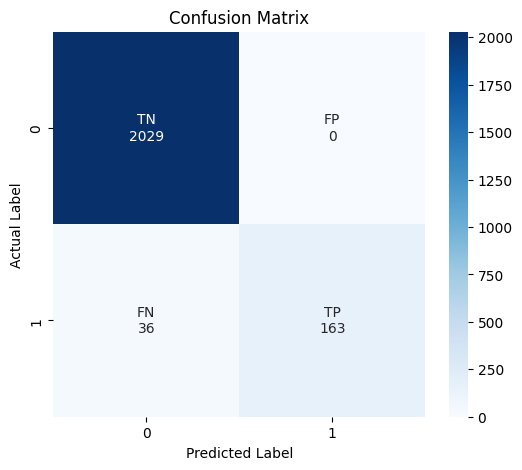

In [55]:

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create labels
labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

# Combine labels with values
annot_labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_labels[i, j] = (
            labels[i, j] + "\n" + str(cm[i, j])
        )

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## ROC Curve

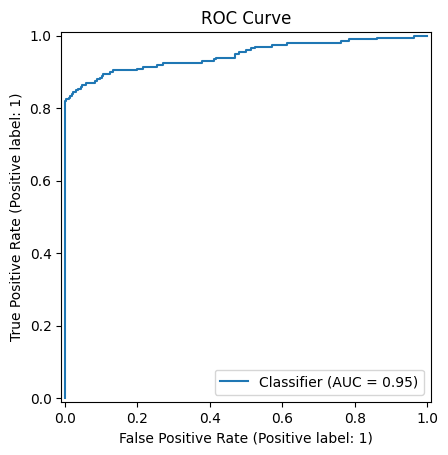

In [56]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.show()

# Initialize XGBoost Model (Advanced Model)

In [57]:
# Initialize XGBoost classifier

from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [58]:
# Train XGBoost model

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [59]:
# Predict fraud classes

y_pred_xgb = xgb_model.predict(X_test)

# Predict fraud probabilities

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

## Evaluate Model Performance

In [60]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Accuracy:", accuracy_xgb)
print("  ")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

XGBoost Accuracy: 0.9833931777378815
  
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2029
           1       0.99      0.82      0.90       199

    accuracy                           0.98      2228
   macro avg       0.99      0.91      0.94      2228
weighted avg       0.98      0.98      0.98      2228



## Generate confusion matrix

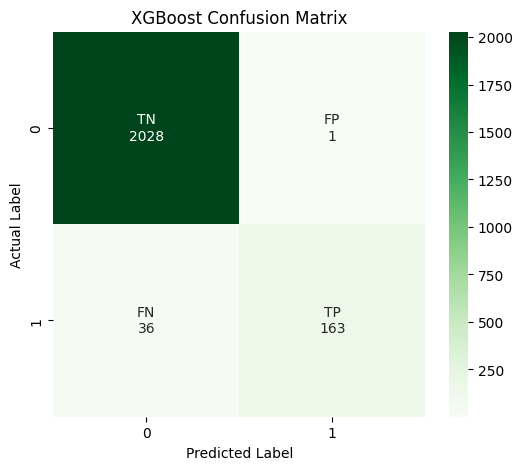

In [61]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

# Labels
labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

# Combine labels with values

annot_labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        annot_labels[i, j] = (
            labels[i, j]
            + "\n"
            + str(cm[i, j])
        )

# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## ROC-AUC Score & ROC Curve

XGBoost ROC-AUC: 0.9308419871659925


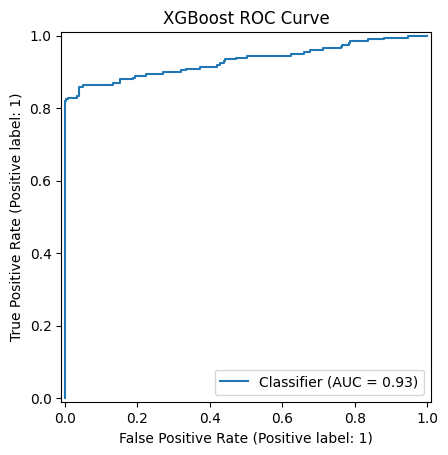

In [62]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", roc_auc_xgb)


RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost ROC Curve")

plt.show()

## Feature Importance

In [63]:


feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort values

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features

print(feature_importance.head(10))

                Feature  Importance
12     txn_velocity_24h    0.671677
11      txn_velocity_1h    0.185599
6         ip_risk_score    0.017121
7      account_age_days    0.012427
10  risk_score_internal    0.011891
39     kyc_tier_unknown    0.005092
23    dest_currency_cny    0.004786
14     transaction_hour    0.004734
27    dest_currency_mxn    0.004653
33          channel_web    0.004529


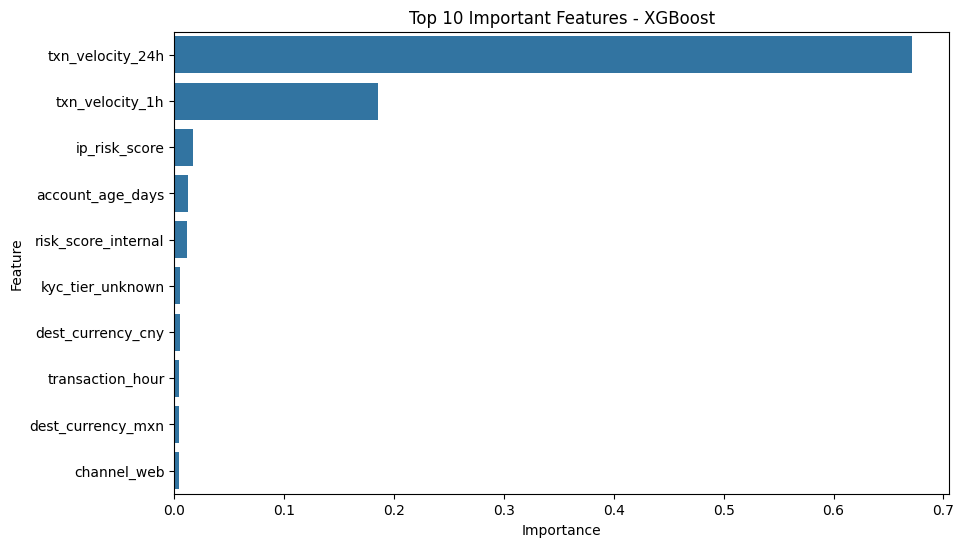

In [64]:
# Visualize top features

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features - XGBoost")

plt.show()

# Hyperparameter Tuning for XGBoost

In [65]:
# Initialize XGBoost model
from sklearn.model_selection import RandomizedSearchCV


xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Define hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [1, 5, 10]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="recall",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning model
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Recall Score:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.7, 'scale_pos_weight': 10, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}

Best Recall Score:
0.8199108351245921


In [66]:
# =========================================
# Evaluate Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# Predictions
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Classification report
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# ROC-AUC
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)
print("Tuned XGBoost ROC-AUC:", roc_auc_tuned)

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2029
           1       0.80      0.83      0.81       199

    accuracy                           0.97      2228
   macro avg       0.89      0.90      0.90      2228
weighted avg       0.97      0.97      0.97      2228

Tuned XGBoost ROC-AUC: 0.9345297210547561


# Compare Model Performance (Log. Reg (Baseline), XGBoost, Tuned XGBoost)

In [ ]:
# =========================================
# Import Evaluation Metrics
# =========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================
# Logistic Regression Metrics
# =========================================

accuracy_log = accuracy_score(y_test, y_pred)
precision_log = precision_score(y_test, y_pred)
recall_log = recall_score(y_test, y_pred)
f1_log = f1_score(y_test, y_pred)
roc_auc_log = roc_auc_score(y_test, y_prob)

# =========================================
# XGBoost Metrics
# =========================================

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# =========================================
# Tuned XGBoost Metrics
# =========================================

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)


NameError: name 'y_pred_log' is not defined

In [ ]:
# Create model comparison table

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Tuned XGBoost"
    ],

    "Accuracy": [
        accuracy_log,
        accuracy_xgb,
        accuracy_tuned
    ],

    "Precision": [
        precision_log,
        precision_xgb,
        precision_tuned
    ],

    "Recall": [
        recall_log,
        recall_xgb,
        recall_tuned
    ],

    "F1-Score": [
        f1_log,
        f1_xgb,
        f1_tuned
    ],

    "ROC-AUC": [
        roc_auc_log,
        roc_auc_xgb,
        roc_auc_tuned
    ]
})

print(comparison_df)